Nama : Zaki Yamani Quthub

NIM : 09021282429096

# Tugas Pengolahan Citra Segmentasi

## A. terdapat 1 gambar berbasis grayscale, gambar tersebut akan dilakukan segementasi menggunakan Global thresholing dan Otsu

(np.float64(-0.5), np.float64(1199.5), np.float64(1599.5), np.float64(-0.5))

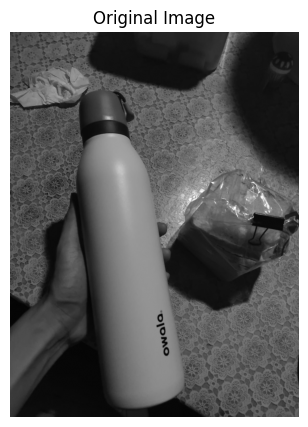

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('gambar.jpeg', cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(img, cmap='gray')
plt.axis('off')

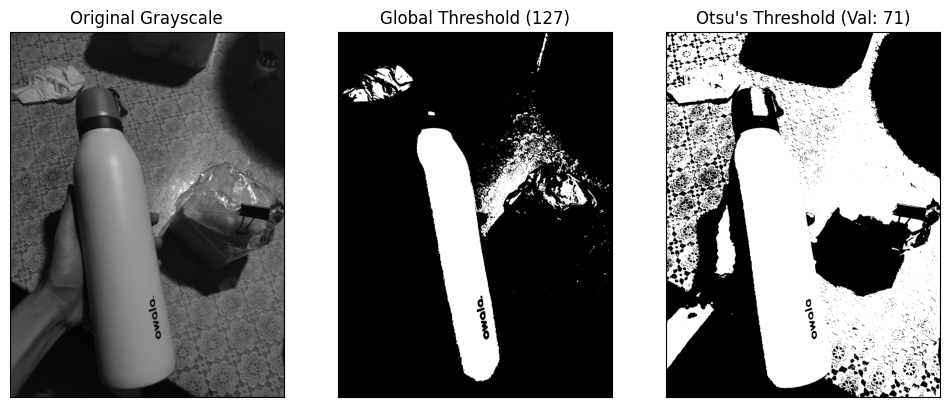

In [6]:
# 2. Global Thresholding (Misal kita set threshold di nilai 127)
 # Semua piksel > 127 menjadi 255 (putih), sisanya 0 (hitam)
ret, thresh_global = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# 3. Otsu's Thresholding
# Nilai threshold dicari otomatis oleh algoritma
ret_otsu, thresh_otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Visualisasi
titles = ['Original Grayscale', 'Global Threshold (127)', f"Otsu's Threshold (Val: {int(ret_otsu)})"]
images = [img, thresh_global, thresh_otsu]

plt.figure(figsize=(12, 5))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(images[i], 'gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.show()
    

## B. segmentasi dengan metode clustering, menggunakan berbagai jumlah K

(np.float64(-0.5), np.float64(1199.5), np.float64(1599.5), np.float64(-0.5))

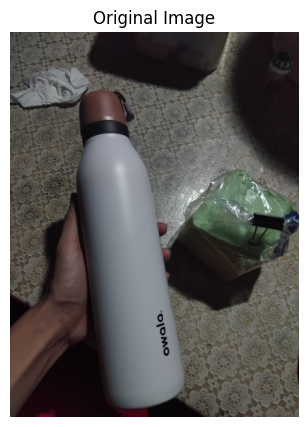

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('gambar.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(img_rgb)
plt.axis('off')

In [11]:
def segment_kmeans(image_path, k_values):

    # Ubah bentuk gambar menjadi list piksel (3 channel: R, G, B)
    pixel_values = img_rgb.reshape((-1, 3))
    pixel_values = np.float32(pixel_values)

    # Kriteria iterasi (berhenti jika sudah 100 iterasi atau akurasi 0.2)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

    plt.figure(figsize=(15, 5))
    
    # Tampilkan gambar asli
    plt.subplot(1, len(k_values) + 1, 1)
    plt.imshow(img_rgb)
    plt.title("Original")
    plt.axis('off')

    for i, k in enumerate(k_values):
        # Jalankan K-Means
        _, labels, centers = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
        
        # Konversi kembali pusat cluster ke unit 8-bit
        centers = np.uint8(centers)
        
        # Mapping piksel ke warna pusat cluster-nya
        segmented_data = centers[labels.flatten()]
        segmented_image = segmented_data.reshape((img_rgb.shape))
        
        # Visualisasi
        plt.subplot(1, len(k_values) + 1, i + 2)
        plt.imshow(segmented_image)
        plt.title(f'K = {k}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

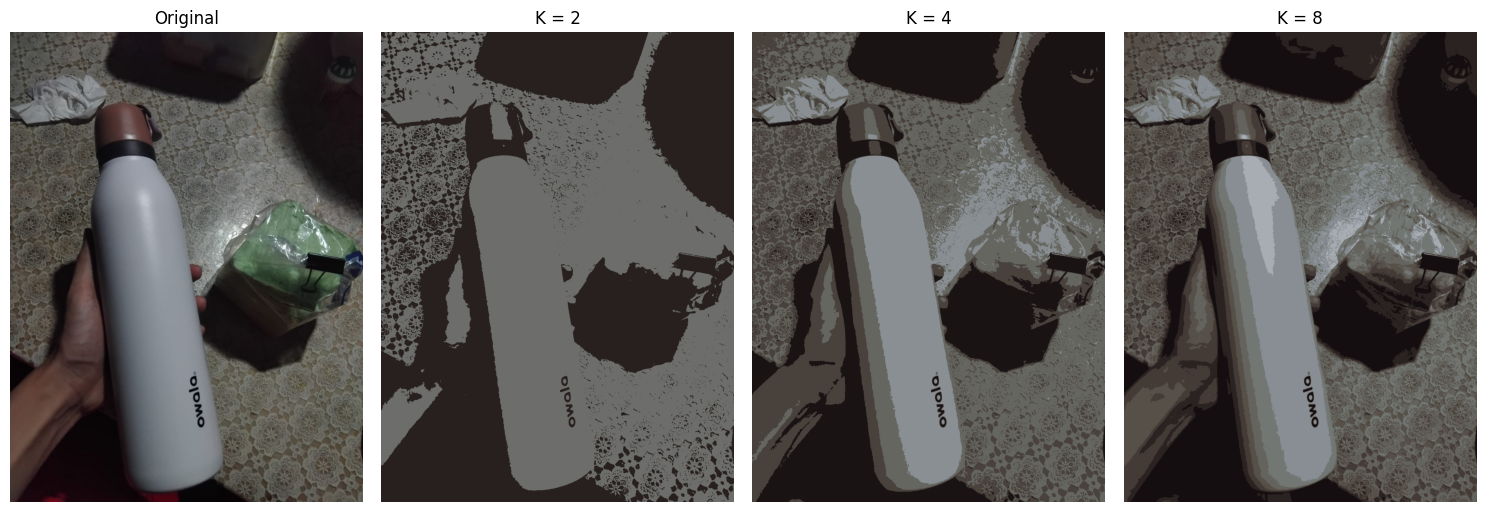

In [12]:
# Jalankan dengan berbagai nilai K (misal: 2, 4, 8)
segment_kmeans('input_gambar_warna.jpg', [2, 4, 8])